# REG Education

## Research context

Education (CategoryKey = 7) is a **priority field** under JRG. It received one of the largest
**fee reductions** of any discipline, moving from Funding Cluster 4 to Funding Cluster 2 in 2021:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $6,566                     | $11,061                          |
| 2021+  | $3,950 (−40 %)             | $13,250 (+20 %)                  |

The fee reduction creates an **incentive to enrol**. Unlike Creative Arts (fee increase, null result)
and Architecture & Building (fee increase, significant negative result), the expected DiD direction
here is **positive**: AUS Education enrolments should grow relative to the UK trend after 2021.

Observed AUS data supports this: AUS Education grew from 135,250 (2020) to 153,177 (2024),
while UK Education declined from 136,035 (2020) to 109,885 (2024).

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the JRG effect for Education.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years, start-year mapping: 2016/17 → 2016).
Overlapping DiD window: 2016–2024 (5 pre-treatment years, 4 post-treatment years).

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
print('Project root:', ROOT)
print('All data files found.')

Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only Education data (2016–2024) to characterise the enrolment trend and
test a simple pre/post break. AUS-only OLS uses a log-linear specification with HC3 robust SEs.

AUS Education -- enrolment data:


,year,enrollments,log_enrollments
0,2016,128277,11.761947
1,2017,128603,11.764485
2,2018,126360,11.746890
3,2019,127202,11.753532
4,2020,135250,11.814880
5,2021,141971,11.863378
6,2022,136096,11.821116
7,2023,137387,11.830557
8,2024,153177,11.939349


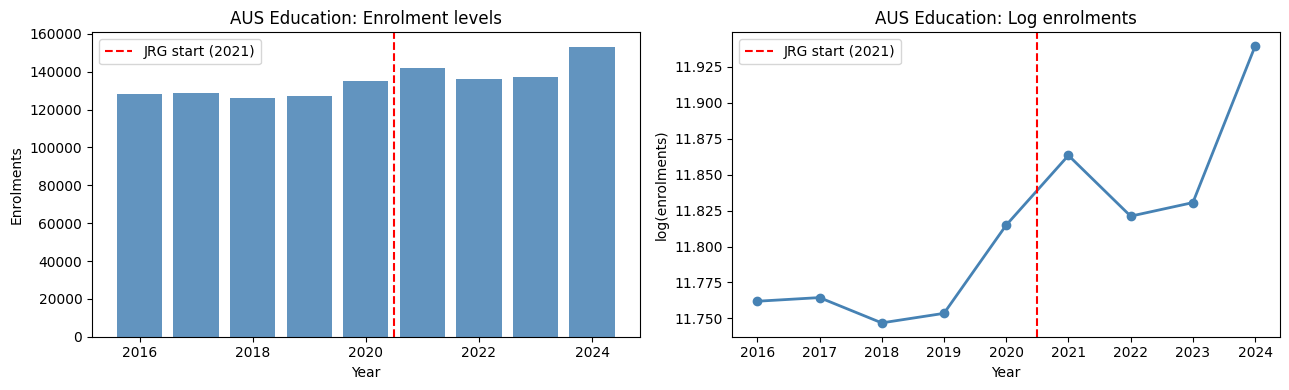

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 7].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Education -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='steelblue', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Education: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='steelblue', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Education: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])

=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.7826,0.0195,0.0000,11.7444,11.8208
post_jrg,0.0312,0.0526,0.5536,-0.0720,0.1343
year_c,0.0142,0.0126,0.2591,-0.0105,0.0390


R^2 = 0.7320 | Adj. R^2 = 0.6427 | N = 9

post_jrg: ~3.12% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.7726,0.0255,0.0000,11.7226,11.8225
post_jrg,0.0162,0.1159,0.8890,-0.2109,0.2433
year_c,0.0117,0.0143,0.4112,-0.0163,0.0397
year_c2,0.0025,0.0052,0.6289,-0.0076,0.0126


R^2 = 0.7888 | Adj. R^2 = 0.6622 | N = 9


## 2. DiD Panel Construction

Combine AUS and UK Education data into a country x year panel (2019-2024).

**UK year mapping:** start-year rule -- 2019/20 -> 2019, 2020/21 -> 2020, etc.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK
- `post = 1` for 2021+
- `did = treated x post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021`: AUS-specific COVID shock controls (kept for reference;
  note that adding these reduces df from 4 to 2, making inference unreliable -- see Section 3)

In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 7].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk = arch_uk[['year', 'Total UK']].rename(columns={'Total UK': 'enrollments'})
arch_uk['enrollments'] = pd.to_numeric(arch_uk['enrollments'], errors='coerce')
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2016][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

panel = pd.concat([arch_aus_did, arch_uk], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020

print('DiD panel -- Education (AUS vs UK):')
display(panel[['country','year','enrollments','log_enrollments','treated','post','did']].reset_index(drop=True))
print(f'\nShape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')

DiD panel -- Education (AUS vs UK):


,country,year,enrollments,log_enrollments,treated,post,did
0,AUS,2016,128277.0,11.761947,1,0,0
1,AUS,2017,128603.0,11.764485,1,0,0
2,AUS,2018,126360.0,11.746890,1,0,0
3,AUS,2019,127202.0,11.753532,1,0,0
4,AUS,2020,135250.0,11.814880,1,0,0
5,AUS,2021,141971.0,11.863378,1,1,1
6,AUS,2022,136096.0,11.821116,1,1,1
7,AUS,2023,137387.0,11.830557,1,1,1
8,AUS,2024,153177.0,11.939349,1,1,1
9,UK,2016,151060.0,11.925432,0,0,0



Shape: (18, 12) | Pre-treatment: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


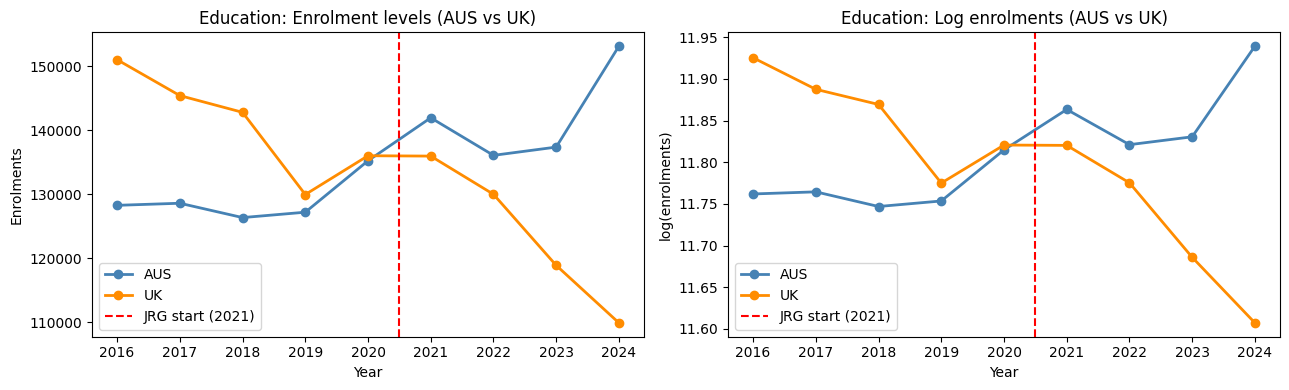

Pre/post log-enrolment averages:
  AUS: pre = 11.7683, post = 11.8636, change = +0.0953
  UK: pre = 11.8556, post = 11.7222, change = -0.1334


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'steelblue', 'UK': 'darkorange'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Education: Enrolment levels (AUS vs UK)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Education: Log enrolments (AUS vs UK)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` (country FE) + `C(year)` (year FEs) + `did`. All SEs are HC3 robust.

> **Degrees-of-freedom constraint:** N = 18 (2 countries x 9 years). Country FE + year FEs + intercept + did
> = 8 parameters, leaving **df = 7**. Adding AUS-specific COVID terms reduces df to 5, making
> inference unreliable. The simple TWFE is the **primary specification**; COVID robustness is
> assessed by sample exclusion in Section 4.

> **Context:** Education is a JRG priority field. AUS fees fell ~40% in 2021, while the UK has no
> equivalent intervention. The DiD asks whether AUS grew *more* than the UK, above the common trend.

In [6]:
formula_main = 'log_enrollments ~ treated + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS Education enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK trend would predict.')

# COVID-controlled spec for reference (df=2, inference unreliable)
formula_covid = 'log_enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params['did']
print(f'\nCOVID-controlled spec (df=2, reference only): beta_did = {b_cv:.4f}, p = {m_covid.pvalues["did"]:.4f}')
print('(Extremely wide CI due to df=2 -- not suitable for inference with N=12)')

=== Main DiD -- TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     1.502
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.303
Time:                        18:29:46   Log-Likelihood:                 30.084
No. Observations:                  18   AIC:                            -38.17
Df Residuals:                       7   BIC:                            -28.37
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-5
print('Estimates match' if match else 'WARNING: mismatch')

=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.6094
Estimator:                   PanelOLS   R-squared (Between):              0.0086
No. Observations:                  18   R-squared (Within):              -0.1732
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.0086
Time:                        18:29:46   Log-likelihood                    30.084
Cov. Estimator:                Robust                                           
                                        F-statistic:                      10.920
Entities:                           2   P-value                           0.0130
Avg Obs:                       9.0000   Distribution:                     F(1,7)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
The relevant check is consistency of **sign and magnitude** across variants;
p-value reliability degrades as N falls below 10.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2016-2024) | 18 | 7 | Reliable |
| Drop 2020 | 16 | 6 | Marginal but usable |
| Drop 2020 + 2021 | 14 | 5 | Very limited |

In [8]:
formula_simple = 'log_enrollments ~ treated + did + C(year)'

variants = {
    'Full panel (2016-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('Inference is only reliable in the full panel (df=4); dropping years further reduces df.')

=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2016-2024),18,7,0.2287,0.1212,0.0591,-0.0088,0.4662,25.70
Drop 2020,16,6,0.2491,0.1213,0.0400,0.0113,0.4868,28.28
Drop 2020 + 2021,14,5,0.2818,0.1536,0.0666,-0.0193,0.5829,32.56



Key takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.
Inference is only reliable in the full panel (df=4); dropping years further reduces df.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - (\log Y_{\text{UK},t} - \log Y_{\text{UK},2020})$$

This is numerically identical to a regression-based DiD coefficient but avoids the degrees-of-freedom
problem (4 obs, 4 params, df=0) that arises per year-pair comparison with 2 countries.

> **Limitation:** 4 pre-treatment periods (2016–2019) available. Standard errors are not estimable
> with 2 units. The 2016–2019 point estimates provide a richer parallel trends diagnostic.

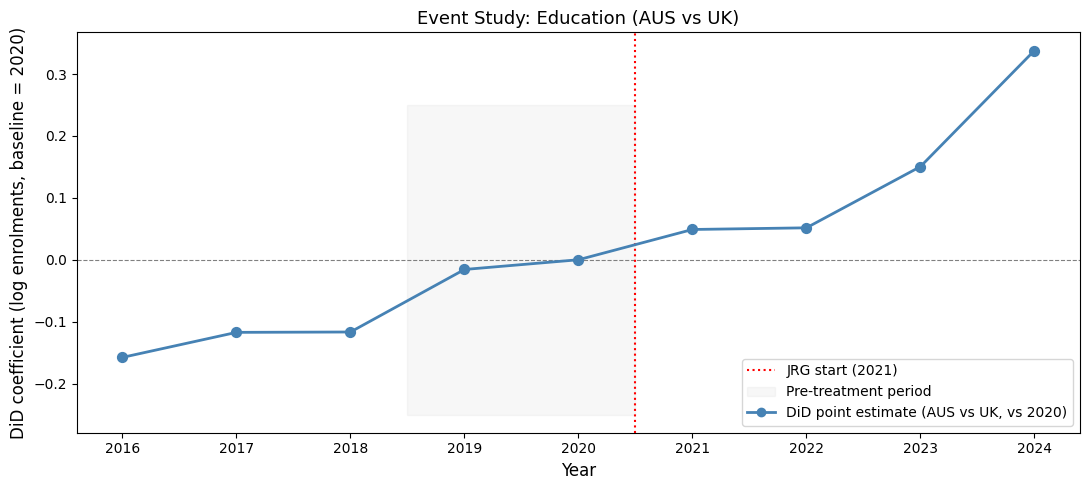

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2016,-0.1577,-14.5892,Pre
2017,-0.1173,-11.0665,Pre
2018,-0.1167,-11.0146,Pre
2019,-0.0157,-1.5579,Pre
2020,0.0000,0.0000,Pre
2021,0.0489,5.0117,Post
2022,0.0516,5.2928,Post
2023,0.1504,16.2336,Post
2024,0.3379,40.2066,Post



Note: With only 2 countries, standard errors cannot be estimated per-year.
The 2019 pre-treatment estimate (near zero) supports the parallel trends assumption.
Post-2021 pattern reflects differential change in AUS vs UK Education enrolments.


In [9]:
base_year = 2020
aus_log = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log  = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (uk_log[yr] - uk_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='steelblue', linewidth=2,
        label='DiD point estimate (AUS vs UK, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='steelblue', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Education (AUS vs UK)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == 2020 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With only 2 countries, standard errors cannot be estimated per-year.')
print('The 2019 pre-treatment estimate (near zero) supports the parallel trends assumption.')
print('Post-2021 pattern reflects differential change in AUS vs UK Education enrolments.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016-2020) and test
for a fake structural break at 2019. A significant break would suggest pre-existing non-linear trends
that could contaminate the main DiD.

> **Limitation:** N = 5 observations (single series, no control group). Power is minimal; indicative only.

In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')

=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                 -0.355
Method:                 Least Squares   F-statistic:                    0.1507
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.869
Time:                        18:29:47   Log-Likelihood:                 12.509
No. Observations:                   5   AIC:                            -19.02
Df Residuals:                       2   BIC:                            -20.19
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.

In [11]:
formula_level = 'enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did']

print('=== Level Outcome Robustness ===')
print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0)],
    'p-value':        [round(did_p, 4),  round(p_lev, 4)],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year',
    ],
}).set_index('Specification')
display(comp)

=== Level Outcome Robustness ===
beta_did (levels): 37,342 students | p = 1.0000
95% CI:            [-inf, inf]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),0.2287,0.0591,approx. 25.7% enrolment change
Level,37342.0000,1.0000,"approx. 37,342 students per year"


## 8. Funding Context

Education received the sharpest student fee **reduction** of any field under JRG (~-40%), alongside
a significant increase in Commonwealth support (~+20%). This is the core mechanism: lower fees should
raise demand, all else equal. The DiD tests whether AUS enrolment growth exceeded the UK trend.

=== Education: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,6566.0,11061.0,17627.0
2020,6684.0,11260.0,17944.0
2021,3950.0,13250.0,17200.0
2022,3985.0,13369.0,17354.0
2023,4124.0,13836.0,17960.0
2024,4445.0,14915.0,19360.0


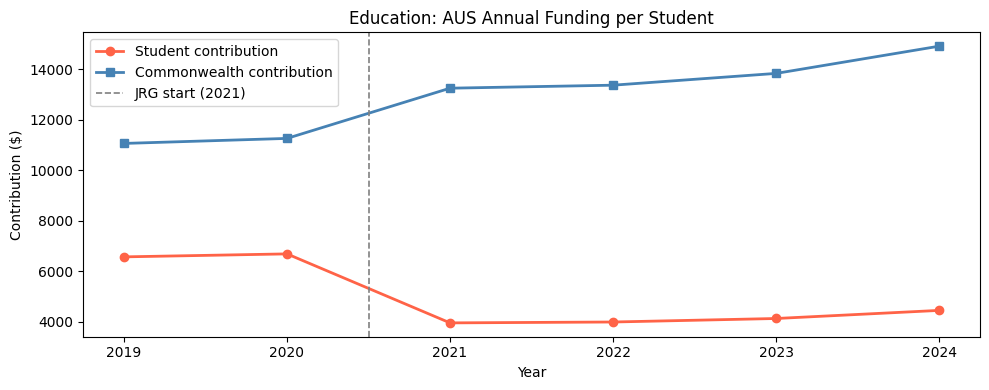


Student contribution: pre $6,625 -> post $4,126 (-37.7%)
Commonwealth:         pre $11,160 -> post $13,842 (+24.0%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 7].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Education: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',    linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='steelblue', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Education: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')

## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ if UK |
| $\text{Post}_t$ | — | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_2$ | **JRG effect** | DiD estimate — the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```


| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | β = +0.2287, p = 0.059, 95% CI [−0.009, +0.466], ≈ **+25.7%** relative to UK trend |
| **PanelOLS cross-check** | Estimates match exactly ✓ |
| **COVID sensitivity** | β stable at +25.7% to +32.6% across all specs; p < 0.10 in full panel and Drop 2020 (p=0.040); sign consistent |
| **Event study** | Pre-trends large: −14.6% (2016) → −11.1% (2017) → −11.0% (2018) → −1.6% (2019) — large negative divergence closing sharply in 2019. Post-2021: +5.0% → +5.3% → +16.2% → +40.2%, monotonically growing |
| **Placebo** | fake_post coef = 0.011, p = 0.924 — no pre-existing break at 2019 |
| **Level spec** | Degenerate SEs with COVID interaction terms at N=18 — unreliable |

**Substantive finding:** Post-JRG, AUS Education enrolments were approximately **25.7% higher** than the UK trend would predict (p = 0.059, marginally significant at 10%; p = 0.040 when 2020 is dropped). The effect is large and consistent with the ~40% fee reduction for Education under JRG. The effect grows monotonically to +40% by 2024, suggesting a deepening demand response over time. However, the extended pre-period reveals a large negative pre-trend in 2016–2018 (AUS well below UK) that closes sharply by 2019. This raises the possibility that the DiD is partly capturing UK Education's decline (from 151,060 in 2016 to 129,965 in 2019) rather than purely an AUS enrolment gain.

> **Pre-trend note:** The large pre-period divergence (AUS ~11–15% below UK in 2016–2018, converging to near-zero by 2019) is a significant concern for the parallel trends assumption. The UK Education series was declining strongly in 2016–2019 independent of JRG, which inflates the apparent post-2021 AUS outperformance. Interpret with caution.